In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df=pd.read_csv("StudentsPerformance.csv")

## Basic Exploration

In [22]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [6]:
df.tail(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [12]:
df.shape

(1000, 8)

In [14]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

# Univariate Analysis

## Distribution of scores (histograms)

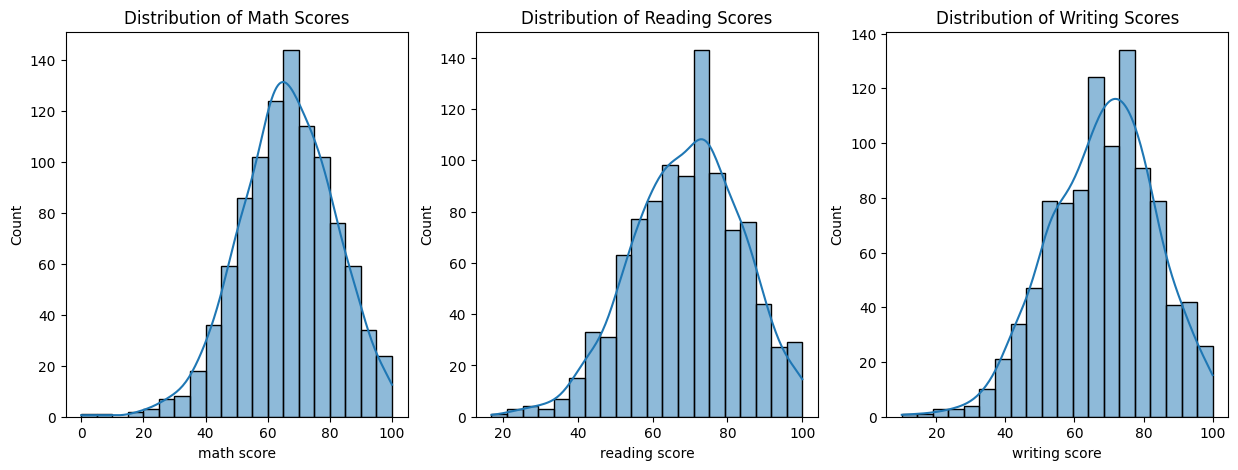

In [19]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(df['math score'], bins=20, kde=True)
plt.title('Distribution of Math Scores')

plt.subplot(1,3,2)
sns.histplot(df['reading score'], bins=20, kde=True)
plt.title('Distribution of Reading Scores')

plt.subplot(1,3,3)
sns.histplot(df['writing score'], bins=20, kde=True)
plt.title('Distribution of Writing Scores')

plt.show()

## Count plot for: gender, lunch, test preparation course

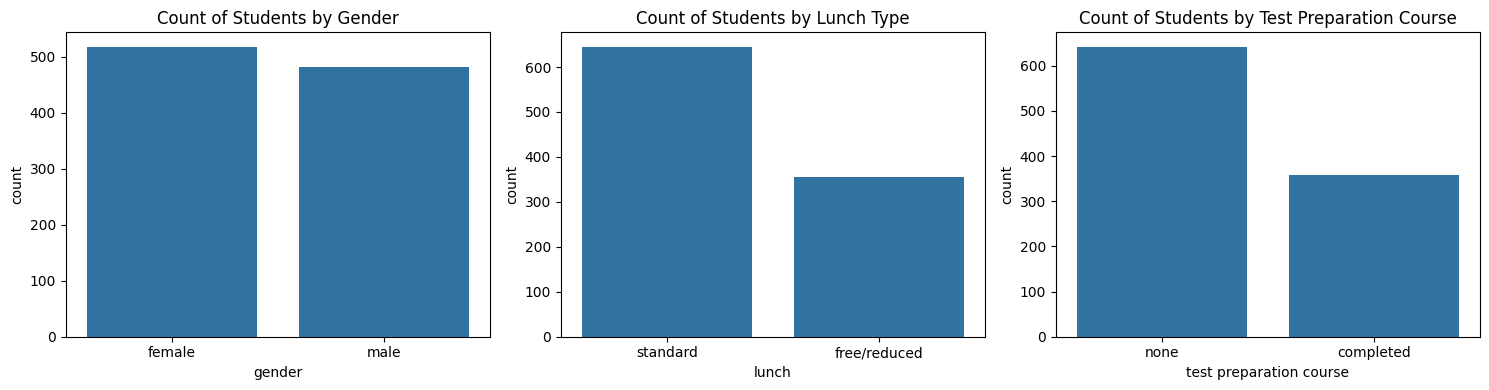

In [28]:
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
sns.countplot(x='gender', data=df)
plt.title('Count of Students by Gender')

plt.subplot(1,3,2)
sns.countplot(x='lunch', data=df)
plt.title('Count of Students by Lunch Type')

plt.subplot(1,3,3)
sns.countplot(x='test preparation course', data=df)
plt.title('Count of Students by Test Preparation Course')

plt.tight_layout()
plt.show()

## Boxplots of math, reading, writing scores

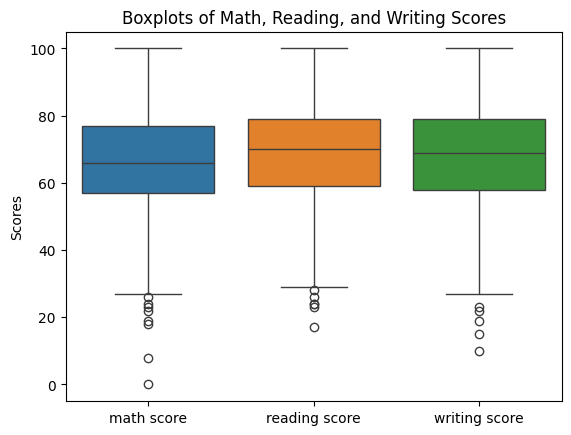

In [29]:
sns.boxplot(data=df[['math score', 'reading score', 'writing score']])

plt.title('Boxplots of Math, Reading, and Writing Scores')
plt.ylabel('Scores')
plt.show()

# Bivariate Analysis


## Scores Based on Gender

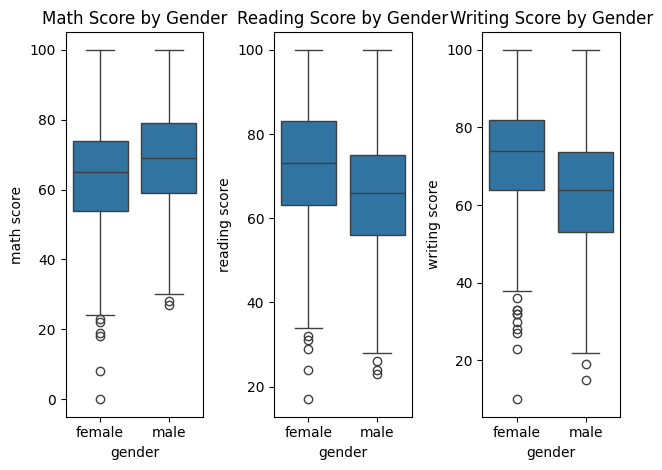

In [31]:
plt.subplot(1,3,1)
sns.boxplot(x='gender', y='math score', data=df)
plt.title('Math Score by Gender')

plt.subplot(1,3,2)
sns.boxplot(x='gender', y='reading score', data=df)
plt.title('Reading Score by Gender')

plt.subplot(1,3,3)
sns.boxplot(x='gender', y='writing score', data=df)
plt.title('Writing Score by Gender')

plt.tight_layout()
plt.show()

## Compare Scores by Lunch Type

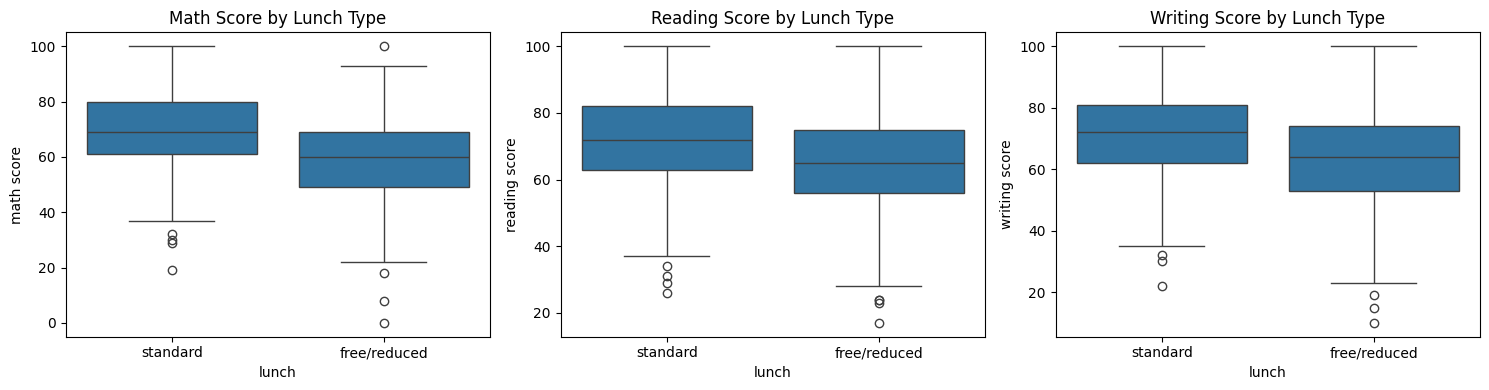

In [33]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.boxplot(x='lunch', y='math score', data=df)
plt.title('Math Score by Lunch Type')

plt.subplot(1,3,2)
sns.boxplot(x='lunch', y='reading score', data=df)
plt.title('Reading Score by Lunch Type')

plt.subplot(1,3,3)
sns.boxplot(x='lunch', y='writing score', data=df)
plt.title('Writing Score by Lunch Type')

plt.tight_layout()
plt.show()

## Scores by Test Preparation Cours

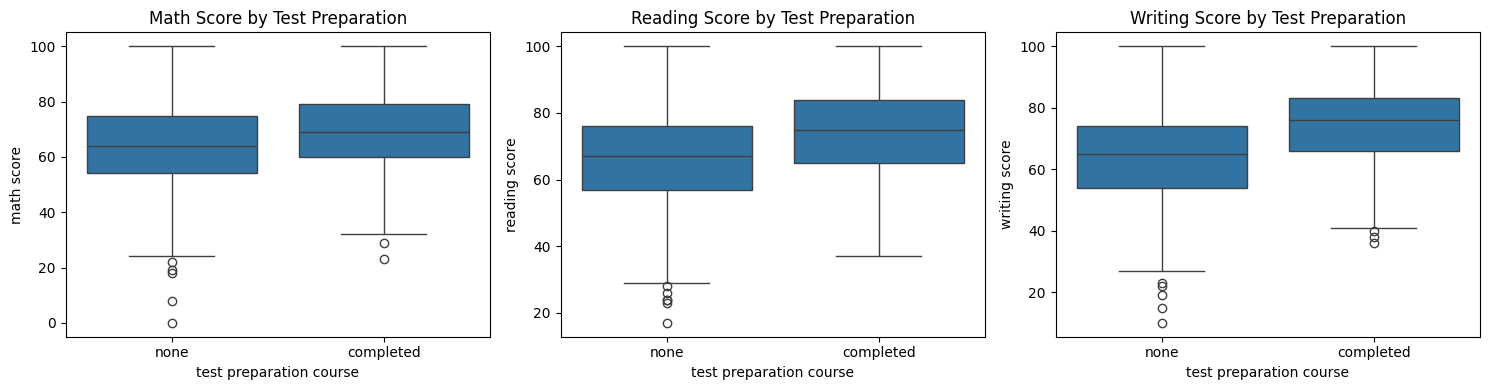

In [35]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.boxplot(x='test preparation course', y='math score', data=df)
plt.title('Math Score by Test Preparation')

plt.subplot(1,3,2)
sns.boxplot(x='test preparation course', y='reading score', data=df)
plt.title('Reading Score by Test Preparation')

plt.subplot(1,3,3)
sns.boxplot(x='test preparation course', y='writing score', data=df)
plt.title('Writing Score by Test Preparation')

plt.tight_layout()
plt.show()

## Correlation Heatmap Between Scores

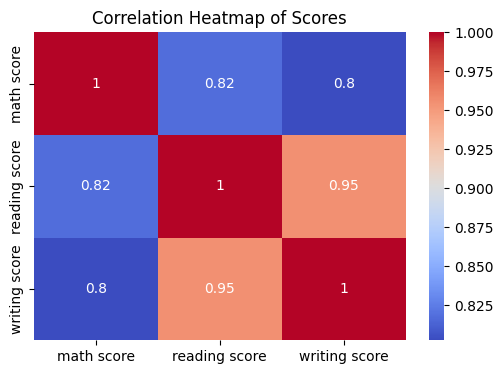

In [38]:
plt.figure(figsize=(6,4))

corr = df[['math score', 'reading score', 'writing score']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Scores')
plt.show()

## Gender Distribution

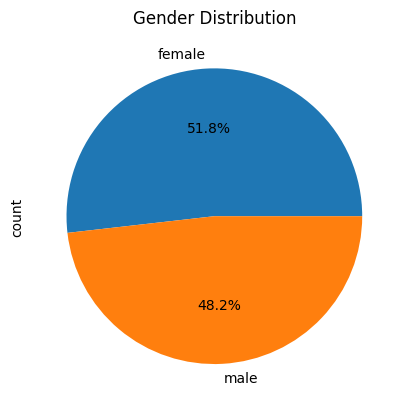

In [52]:
df['gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

## Does Parental Education Affect Student Scores?

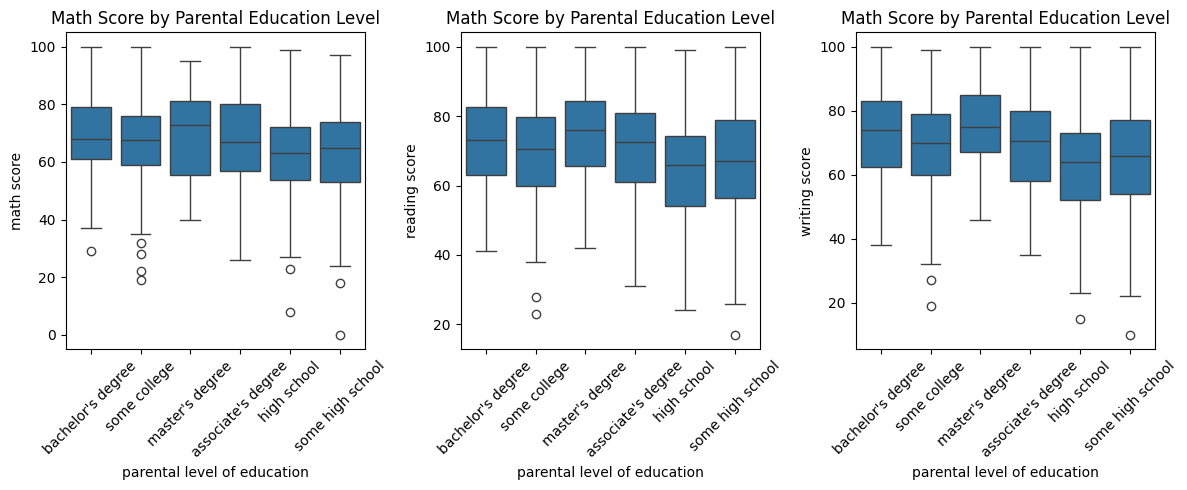

In [40]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
sns.boxplot(x='parental level of education', y='math score', data=df)
plt.xticks(rotation=45)
plt.title('Math Score by Parental Education Level')

plt.subplot(1,3,2)
sns.boxplot(x='parental level of education', y='reading score', data=df)
plt.xticks(rotation=45)
plt.title('Math Score by Parental Education Level')

plt.subplot(1,3,3)
sns.boxplot(x='parental level of education', y='writing score', data=df)
plt.xticks(rotation=45)
plt.title('Math Score by Parental Education Level')
plt.tight_layout()
plt.show()

## Average Score

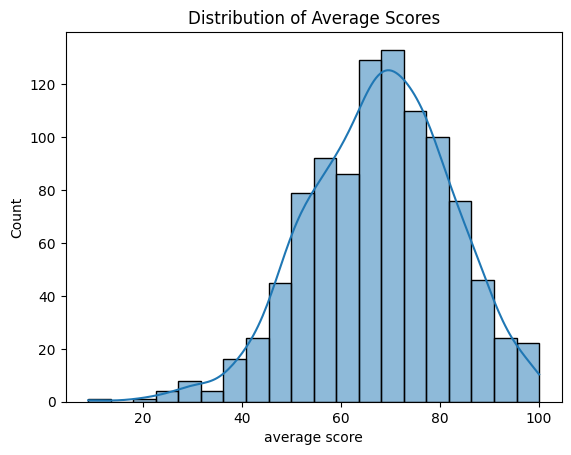

In [42]:
df['average score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

# Distribution of overall performance
sns.histplot(df['average score'], bins=20, kde=True)
plt.title('Distribution of Average Scores')
plt.show()

## Overall Analysis

In [44]:
# Average score by gender
df.groupby('gender')['average score'].mean()


gender
female    69.569498
male      65.837483
Name: average score, dtype: float64

In [45]:
# Average score by test preparation
df.groupby('test preparation course')['average score'].mean()

test preparation course
completed    72.669460
none         65.038941
Name: average score, dtype: float64

In [46]:
# Average score by lunch
df.groupby('lunch')['average score'].mean()

lunch
free/reduced    62.199061
standard        70.837209
Name: average score, dtype: float64